In [1]:
# get root path and add to sys.path
import os
import sys
from pathlib import Path
import dotenv
import json
import importlib


dotenv.load_dotenv()

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))


import json
from functions.sqldatabase_langchain_utils import SQLDatabaseLangchainUtils

experiment = os.getenv("EXPERIMENT_NAME")

with open(root_path / f"connections/{experiment}_db_connection.json", "r") as f:
    db_connection = json.load(f)

dataset_module_path = f"eval_agent.dataset_generation.experiments_datasets.{experiment}_dataset"
dataset_module = importlib.import_module(dataset_module_path)
include_tables = dataset_module.DATABASE_TABLES
print(len(include_tables), "tables will be included in the database schema.")

samples = 3
view_support = False

db = SQLDatabaseLangchainUtils(db_connection=db_connection, include_tables=include_tables, samples=samples, view_support=view_support)

schema = os.getenv("EXPERIMENT_SCHEMA")
print(f"Using schema: {schema}")
table_info = db.get_table_info().replace(f'"{schema}".', "")
# table_info = db.get_table_info().replace(f'"{schema.lower()}".', "")

17 tables will be included in the database schema.
Using schema: BIRD_DEV


In [2]:
print(table_info)


CREATE TABLE formula_1_circuits (
	circuitid NUMBER(38, 0) NOT NULL, 
	circuitref VARCHAR(40 CHAR), 
	name VARCHAR(128 CHAR), 
	location VARCHAR(40 CHAR), 
	country VARCHAR(26 CHAR), 
	lat NUMBER(38, 5), 
	lng NUMBER(38, 6), 
	alt NUMBER(38, 0), 
	url VARCHAR(400 CHAR) DEFAULT '', 
	CONSTRAINT pk_circuits PRIMARY KEY (circuitid)
)
 TABLESPACE "BIRD_DEV"

/*
3 rows from formula_1_circuits table:
circuitid	circuitref	name	location	country	lat	lng	alt	url
2	sepang	Sepang International Circuit	Kuala Lumpur	Malaysia	2.76083	101.738	None	http://en.wikipedia.org/wiki/Sepang_International_Circuit
3	bahrain	Bahrain International Circuit	Sakhir	Bahrain	26.0325	50.5106	None	http://en.wikipedia.org/wiki/Bahrain_International_Circuit
4	catalunya	Circuit de Barcelona-Catalunya	Montmeló	Spain	41.57	2.26111	None	http://en.wikipedia.org/wiki/Circuit_de_Barcelona-Catalunya
*/


CREATE TABLE formula_1_constructorresults (
	constructorresultsid NUMBER(38, 0) NOT NULL, 
	raceid NUMBER(38, 0), 
	constructo

In [3]:
def structured_table_info(table_info):
    """
    Função que recebe a string de informações da tabela e 
    """
    tables_dict = {}
    
    # Split the table_info by CREATE TABLE to identify each table definition
    table_blocks = table_info.split("CREATE TABLE ")
    
    for block in table_blocks:
        if not block.strip():
            continue

        # Extract table name
        table_name = block.split('(')[0].strip()

        tables_dict[table_name] = "CREATE TABLE " + block
        
    return tables_dict

table_ddls_hashmap = structured_table_info(table_info)
print(table_ddls_hashmap[include_tables[0]])

CREATE TABLE formula_1_circuits (
	circuitid NUMBER(38, 0) NOT NULL, 
	circuitref VARCHAR(40 CHAR), 
	name VARCHAR(128 CHAR), 
	location VARCHAR(40 CHAR), 
	country VARCHAR(26 CHAR), 
	lat NUMBER(38, 5), 
	lng NUMBER(38, 6), 
	alt NUMBER(38, 0), 
	url VARCHAR(400 CHAR) DEFAULT '', 
	CONSTRAINT pk_circuits PRIMARY KEY (circuitid)
)
 TABLESPACE "BIRD_DEV"

/*
3 rows from formula_1_circuits table:
circuitid	circuitref	name	location	country	lat	lng	alt	url
2	sepang	Sepang International Circuit	Kuala Lumpur	Malaysia	2.76083	101.738	None	http://en.wikipedia.org/wiki/Sepang_International_Circuit
3	bahrain	Bahrain International Circuit	Sakhir	Bahrain	26.0325	50.5106	None	http://en.wikipedia.org/wiki/Bahrain_International_Circuit
4	catalunya	Circuit de Barcelona-Catalunya	Montmeló	Spain	41.57	2.26111	None	http://en.wikipedia.org/wiki/Circuit_de_Barcelona-Catalunya
*/





In [4]:
pop = []
for k in table_ddls_hashmap.keys():
    if k not in include_tables:
        pop.append(k)
for k in pop:
    table_ddls_hashmap.pop(k)
print(table_ddls_hashmap.keys())


dict_keys(['formula_1_circuits', 'formula_1_constructorresults', 'formula_1_constructors', 'formula_1_constructorstandings', 'formula_1_drivers', 'formula_1_driverstandings', 'formula_1_laptimes', 'formula_1_pitstops', 'formula_1_qualifying', 'formula_1_races', 'formula_1_results', 'formula_1_seasons', 'formula_1_status', 'formula_1_tmdc', 'formula_1_tmdp', 'formula_1_tmjmap', 'formula_1_tpv'])


### Parsing table-description json into per-table columns

In [5]:
import json
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple, Any, Union

@dataclass
class ColumnMeta:
    table_idx: int
    table_name: str
    name: str
    description: str
    col_type: str
    original_name: Optional[str] = None
    normalized_name: Optional[str] = None

def _extract_db_objects(data: Any) -> List[dict]:
    """
    Accepts:
      - a list of db objects  -> returns it
      - a dict with a list under common keys -> returns that list
      - a single db object -> returns [that object]
    """
    if isinstance(data, list):
        return data

    if isinstance(data, dict):
        # common wrappers
        for k in ("databases", "dbs", "schemas", "items"):
            if k in data and isinstance(data[k], list):
                return data[k]

        # looks like a single db object (Spider-like)
        if "table_names_original" in data and "column_names" in data:
            return [data]

    raise ValueError(
        "Unsupported JSON format. Expected a list of db objects, a wrapper dict containing a list, "
        "or a single Spider-like db object."
    )

def load_dataset_description(path: str) -> Tuple[Dict[str, Dict[str, List[ColumnMeta]]], Any]:
    """
    For a JSON containing MANY databases, returns:

      - columns_by_db_and_table:
            { db_id: { table_name_original: [ColumnMeta, ...] } }

      - raw_json: the full loaded JSON (list or dict)
    """
    with open(path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    db_objects = _extract_db_objects(raw)

    columns_by_db_and_table: Dict[str, Dict[str, List[ColumnMeta]]] = {}

    for db_obj in db_objects:
        db_id = db_obj.get("db_id", "UNKNOWN_DB")

        table_names = db_obj["table_names_original"]  # e.g. ["betfront", "football_data"]
        col_descs = db_obj.get("column_descriptions", None)
        col_types = db_obj["column_types"]
        col_names = db_obj["column_names"]  # [[-1,"*"], [0,"year"], ...]
        col_names_orig = db_obj.get("column_names_original", None)
        col_names_norm = db_obj.get("column_names_manually_normalized_alternative", None)

        columns_by_table: Dict[str, List[ColumnMeta]] = {t: [] for t in table_names}

        for i, (tidx, cname) in enumerate(col_names):
            if tidx == -1 or cname.strip() == "*":
                continue

            tname = table_names[tidx]
            cm = ColumnMeta(
                table_idx=tidx,
                table_name=tname,
                name=cname,
                description=col_descs[i] if col_descs and i < len(col_descs) else cname,
                col_type=col_types[i] if i < len(col_types) else "text",
                original_name=(col_names_orig[i][1] if col_names_orig else None),
                normalized_name=(col_names_norm[i][1] if col_names_norm else None),
            )
            columns_by_table[tname].append(cm)

        columns_by_db_and_table[db_id] = columns_by_table

    return columns_by_db_and_table, raw


### Columns Combinations that "makes sense"

- Instead of “all combinations of columns” (which is huge and mostly nonsense), produce query-blueprints. These are easy to turn into synthetic dialogue turns later

In [6]:
from pydantic import BaseModel, Field
from typing import List, Literal, Optional

class ColumnRef(BaseModel):
    table: str = Field(..., description="Table name within the database (original, unprefixed)")
    column: str = Field(..., description="Column name (as in column_names)")

class AggSpec(BaseModel):
    func: Literal["count", "sum", "avg", "min", "max"] = Field(...)
    column: Optional[ColumnRef] = Field(None, description="None only allowed for count(*)")

class FilterSpec(BaseModel):
    column: ColumnRef
    op: Literal["=", "!=", "<", "<=", ">", ">=", "between", "in", "like"] = Field(...)
    value_hint: str = Field(..., description="Example placeholder: '<YEAR>', '<COUNTRY>', '<TEAM>'")

class QueryBlueprint(BaseModel):
    db_id: str = Field(..., description="Database identifier this combo belongs to (e.g., 'geonucleardata')")
    tables: List[str] = Field(
        ...,
        description="Tables involved within this db (original, unprefixed). Use 1 for single-table queries."
    )
    select: List[ColumnRef] = Field(..., description="Columns to project (dimensions)")
    aggregations: List[AggSpec] = Field(default_factory=list)
    group_by: List[ColumnRef] = Field(default_factory=list)
    filters: List[FilterSpec] = Field(default_factory=list)
    order_by: Optional[ColumnRef] = None
    order_dir: Optional[Literal["asc", "desc"]] = None
    rationale: str = Field(..., description="Why this combo is meaningful / intended question type")

class ColumnCombosOutput(BaseModel):
    combos: List[QueryBlueprint]



### Combo Generation Loop

- Build a compact “schema summary” per table from the JSON

In [7]:
from tqdm import tqdm
import os
from typing import Dict, List
from functions.llm_config import LLMConfig

def format_table_columns_for_prompt(columns_by_table: Dict[str, List[ColumnMeta]]) -> str:
    lines = []
    for tname, cols in columns_by_table.items():
        lines.append(f"TABLE: {tname}")
        for c in cols:
            nm = c.normalized_name or c.name
            lines.append(f"  - {c.name} (normalized: {nm}) | type: {c.col_type} | desc: {c.description}")
        lines.append("")
    return "\n".join(lines)

# Load dataset description json (NOW multi-db)
columns_by_db_and_table, raw_desc = load_dataset_description(
    f"dataset_description/{experiment}_tables_description.json"
)

llm = LLMConfig(provider=os.getenv("LLM_PROVIDER")).get_llm(model=os.getenv("LLM_MODEL"))
llm_with_structured_output = llm.with_structured_output(ColumnCombosOutput)

all_combos: List[QueryBlueprint] = []

prompt = """
You are generating candidate column combinations that can produce meaningful SQL queries
for synthetic Text-to-SQL dialogue generation.

Rules:
- Prefer SINGLE-TABLE queries unless there are explicit foreign keys (none provided here).
- Each combo should be a realistic query idea.
- Avoid trivial combos (e.g., selecting only one column, or only numeric columns).
- Use these common query patterns when possible:
  (A) aggregation over a dimension: SELECT <dim>, AGG(<measure>) GROUP BY <dim>
  (B) filtering: WHERE <dim/time> <op> <value>
  (C) ordering + top-k: ORDER BY AGG(<measure>) DESC (or by a numeric column)
  (D) time slicing when time columns exist (between, year filter)
- Keep each combo small: 2–5 total referenced columns (including group/filter/agg columns).
- Output 3 to 5 combos for the target table.

Filtering operators:
- FilterSpec.op MUST be one of: =, !=, <, <=, >, >=, between, in, like
- DO NOT use "is null" or "is not null".
- If you want to express NOT NULL, use op "!=" with value_hint "<NULL>".
- If you want to express IS NULL, use op "=" with value_hint "<NULL>".


IMPORTANT:
- You MUST set QueryBlueprint.db_id exactly to: {db_id}
- Use ColumnRef.table exactly as the TABLE name shown (unprefixed, within this db).
- Use ColumnRef.column exactly as listed.

# Database id:
{db_id}

# Full schema summary (tables of this db only):
{schema_summary}

# Target table (within this db):
{target_table}

Structured Output:
"""

# Nice progress bar: total tables across all dbs
total_tables = sum(len(tables) for tables in columns_by_db_and_table.values())

with tqdm(total=total_tables, desc="\nGenerating column-combos per table...") as pbar:
    for db_id, columns_by_table in columns_by_db_and_table.items():
        schema_summary = format_table_columns_for_prompt(columns_by_table)

        for table_name in columns_by_table.keys():
            prompt_with_data = prompt.format(
                db_id=db_id,
                schema_summary=schema_summary,
                target_table=table_name
            )

            result = llm_with_structured_output.invoke(prompt_with_data)

            # Safety: enforce db_id on the python side
            for combo in result.combos:
                combo.db_id = db_id
                all_combos.append(combo)

            pbar.update(1)

print("Total combos generated:", len(all_combos))





Generating column-combos per table...:   9%|▊         | 4/47 [00:22<03:57,  5.52s/it]


KeyboardInterrupt: 

### Prefixing step

In [8]:
def prefix_table(db_id: str, table_name: str) -> str:
    """
    Turns (db_id='geonucleardata', table='nuclear_power_plants')
    into 'geonucleardata_nuclear_power_plants'
    """
    return f"{db_id}_{table_name}"

def apply_prefixing(q: QueryBlueprint) -> QueryBlueprint:
    """
    Mutates and returns q, prefixing:
      - q.tables
      - ColumnRef.table in select/group_by/order_by
      - AggSpec.column.table
      - FilterSpec.column.table
    """
    db_id = q.db_id

    # tables list
    q.tables = [prefix_table(db_id, t) for t in q.tables]

    # select
    for c in q.select:
        c.table = prefix_table(db_id, c.table)

    # group_by
    for c in q.group_by:
        c.table = prefix_table(db_id, c.table)

    # aggregations
    for a in q.aggregations:
        if a.column is not None:
            a.column.table = prefix_table(db_id, a.column.table)

    # filters
    for f in q.filters:
        f.column.table = prefix_table(db_id, f.column.table)

    # order_by
    if q.order_by is not None:
        q.order_by.table = prefix_table(db_id, q.order_by.table)

    return q

# ---- Apply prefixing to everything (do this BEFORE dedup) ----
all_combos = [apply_prefixing(c) for c in all_combos]

### Getting unique combos

In [9]:
def combo_signature(q: QueryBlueprint) -> str:
    def cr(x: ColumnRef) -> str:
        return f"{x.table}.{x.column}"

    parts = []
    parts.append("DB:" + q.db_id)

    # These are already prefixed after apply_prefixing()
    parts.append("T:" + "|".join(sorted(q.tables)))
    parts.append("S:" + "|".join(sorted(cr(c) for c in q.select)))
    parts.append("G:" + "|".join(sorted(cr(c) for c in q.group_by)))
    parts.append("A:" + "|".join(sorted(
        f"{a.func}({cr(a.column) if a.column else '*'})"
        for a in q.aggregations
    )))
    parts.append("F:" + "|".join(sorted(
        f"{cr(f.column)}{f.op}{f.value_hint}"
        for f in q.filters
    )))
    if q.order_by:
        parts.append("O:" + cr(q.order_by) + ":" + (q.order_dir or "asc"))

    return " || ".join(parts)

unique = {}
for c in all_combos:
    unique[combo_signature(c)] = c

all_combos = list(unique.values())
print("After prefixing + dedup:", len(all_combos))


After prefixing + dedup: 65


### Saving results in CSV file

In [10]:
import csv
from typing import List

def colref_to_str(c):
    # c.table is already prefixed: <db_id>_<table>
    return f"{c.table}.{c.column}"

def agg_to_str(a):
    if a.column is None:
        return f"{a.func}(*)"
    return f"{a.func}({colref_to_str(a.column)})"

def filter_to_str(f):
    return f"{colref_to_str(f.column)} {f.op} {f.value_hint}"

def combo_to_csv_row(combo):
    return {
        "db_id": combo.db_id,
        "tables": "|".join(combo.tables),
        "select_columns": "|".join(colref_to_str(c) for c in combo.select),
        "aggregations": "|".join(agg_to_str(a) for a in combo.aggregations),
        "group_by": "|".join(colref_to_str(c) for c in combo.group_by),
        "filters": "|".join(filter_to_str(f) for f in combo.filters),
        "order_by": colref_to_str(combo.order_by) if combo.order_by else "",
        "order_dir": combo.order_dir or "",
        "rationale": combo.rationale,
    }

def save_combos_to_csv(combos: List, output_path: str):
    if not combos:
        raise ValueError("No combos to save")

    fieldnames = [
        "db_id",
        "tables",
        "select_columns",
        "aggregations",
        "group_by",
        "filters",
        "order_by",
        "order_dir",
        "rationale",
    ]

    with open(output_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        for combo in combos:
            writer.writerow(combo_to_csv_row(combo))


In [11]:
output_csv = root_path / f"eval_agent/dataset_generation/columns_combos/{experiment}_columns_combinations.csv"

save_combos_to_csv(all_combos, str(output_csv))

print(f"Saved {len(all_combos)} column combos to {output_csv}")


Saved 65 column combos to /Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/eval_agent/dataset_generation/columns_combos/bird_columns_combinations.csv


### Gerar Joins Combinations entre tabelas

In [12]:


from typing import List
from pydantic import BaseModel, Field
from functions.llm_config import LLMConfig

class Join(BaseModel):
    from_: str = Field(..., alias="from", description="Origin table of the join")
    to: str = Field(..., description="Destiny table of the join")
    on: List[str] = Field(..., description="Fully qualified join conditions in the format 'TABLE1.COLUMN1=TABLE2.COLUMN2'")
    
class FirstStepOutputFormat(BaseModel):
    joins: List[Join] = Field(..., description="List of possible joins between tables")
    
# Inicializar o modelo de linguagem para a extração dos joins

llm = LLMConfig(provider=os.getenv("LLM_PROVIDER")).get_llm(model=os.getenv("LLM_MODEL"))
llm_with_structured_output = llm.with_structured_output(FirstStepOutputFormat)

In [13]:
from tqdm import tqdm

FULL_SCHEMA = table_info

joins = []

for table in tqdm(table_ddls_hashmap, desc="\nFinding join combinations..."):
    prompt = """
Given the schema of the database, generate all possible join combinations between table i'll give you and the other tables in schema. Use PK and FK informations for that, and consider that the tables are connected by a single join.

Be very careful with composed keys, they are a combination of two or more columns that are used to reference another table.

Be very careful to not create joins that don't exist in the schema. There can be tables that are not connected at all.

For each join condition, use the fully qualified column name format: 'TABLE1.COLUMN1=TABLE2.COLUMN2'

Examples of the required format:
- For a simple join: 
  Join(from_='DATABASE_TABLE_1', to='DATABASE_TABLE_2', on=['DATABASE_TABLE_2.FK_COLUMN=DATABASE_TABLE_1.PK_COLUMN'])

- For a compound join:
  Join(from_='DATABASE_TABLE_1', to='DATABASE_TABLE_2', on=['DATABASE_TABLE_2.FK_COLUMN=DATABASE_TABLE_1.PK_COLUMN'])

# Full Schema:
{full_schema}
 
# Target table:
{target_table}

BE CAREFUL TO NOT MISS ANY JOIN, AND DON'T CREATE A JOIN THAT DOESN'T EXIST IN THE SCHEMA. ALSO DON'T FORGET ANY TABLE IN THE SCHEMA.
Structured Output:
"""
    prompt_with_schema = prompt.format(full_schema=FULL_SCHEMA, target_table=table_ddls_hashmap[table])

    result = llm_with_structured_output.invoke(prompt_with_schema)
    
    for join in result.joins:
        joins.append(join)


Finding join combinations...: 100%|██████████| 17/17 [00:44<00:00,  2.62s/it]


In [14]:
# Create a dictionary to track unique joins
seen_joins = {}
unique_joins = []

# Function to normalize join conditions for comparison
def normalize_join(join):
    # Create a canonical representation of the join
    # Sort conditions and normalize table order
    from_table = join.from_
    to_table = join.to
    
    # Normalize the join conditions
    normalized_conditions = []
    for condition in join.on:
        # Split the condition into left and right parts
        parts = condition.split('=')
        left = parts[0].strip()
        right = parts[1].strip()
        
        # Extract table names from the conditions
        left_table = left.split('.')[0]
        right_table = right.split('.')[0]
        
        # Ensure consistent ordering of tables in the condition
        if left_table > right_table:
            normalized_conditions.append(f"{right}={left}")
        else:
            normalized_conditions.append(f"{left}={right}")
    
    # Sort the normalized conditions
    normalized_conditions.sort()
    
    # Create a key with tables sorted alphabetically
    tables = sorted([from_table, to_table])
    return (tables[0], tables[1], tuple(normalized_conditions))

# Count original joins
original_count = len(joins)

# Filter out duplicate joins
for join in joins:
    key = normalize_join(join)
    if key not in seen_joins:
        seen_joins[key] = join
        unique_joins.append(join)

# Replace the original joins list with unique joins
joins = unique_joins

print(f"Removed {original_count - len(unique_joins)} duplicate joins")


Removed 19 duplicate joins


Grafo construído com 16 tabelas e 31 joins possíveis
Total de tabelas no esquema: 16
Primeiras 10 tabelas: ['formula_1_circuits', 'formula_1_races', 'formula_1_constructorresults', 'formula_1_constructors', 'formula_1_constructorstandings', 'formula_1_results', 'formula_1_qualifying', 'formula_1_drivers', 'formula_1_driverstandings', 'formula_1_laptimes']


/var/folders/vx/6n609lh96v91_0jh1hzlvn5w0000gn/T/ipykernel_8907/3799037941.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


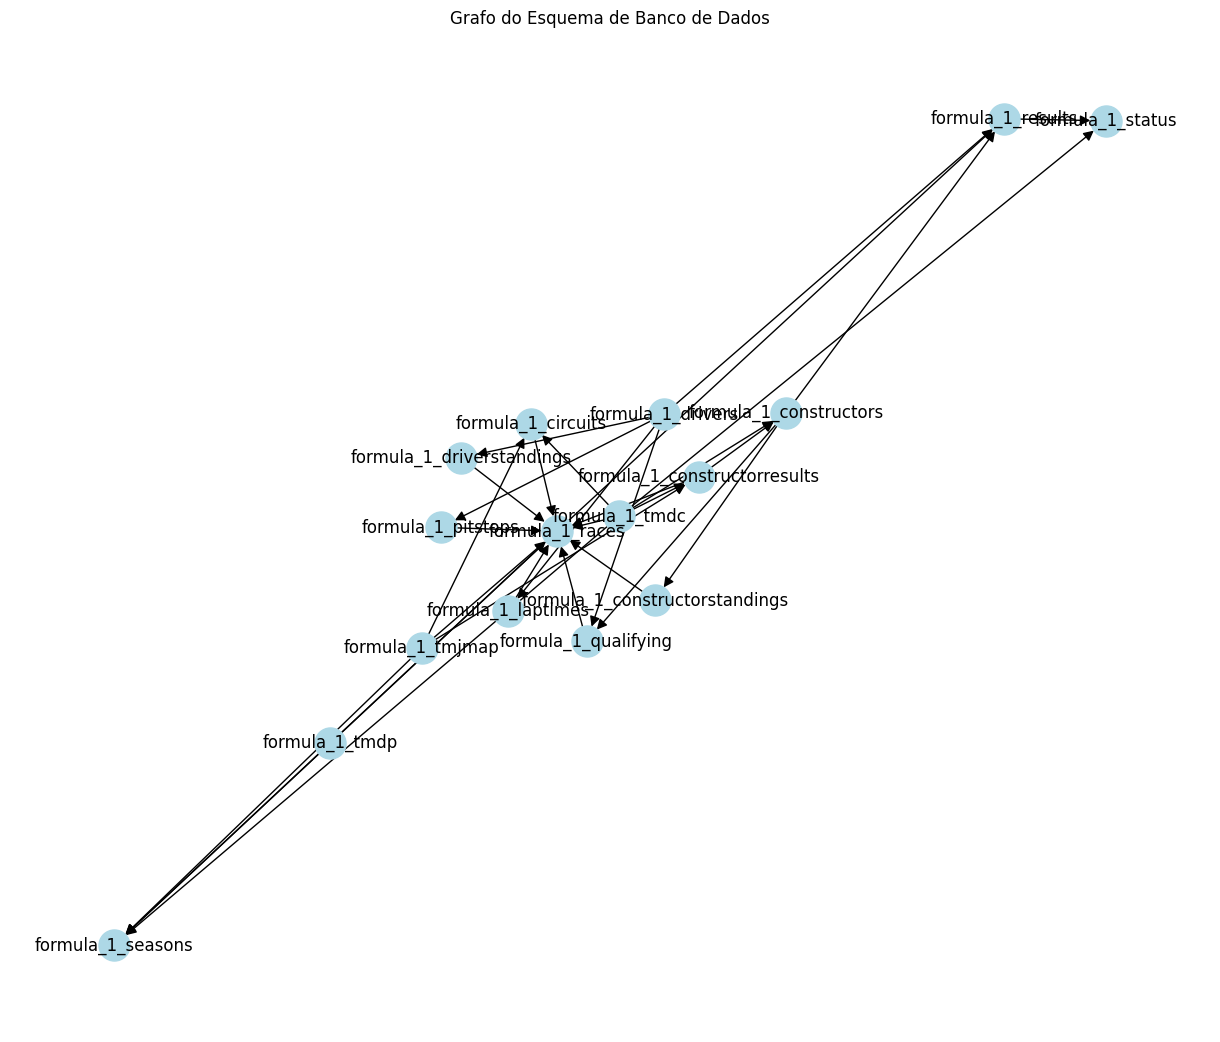

In [15]:
# Célula 1: Construir grafo de tabelas e joins
import networkx as nx
import matplotlib.pyplot as plt
import random
from collections import Counter, defaultdict
import pandas as pd

def build_schema_graph(joins):
    """
    Constrói um grafo representando o esquema do banco de dados.
    - Nós: tabelas
    - Arestas: joins entre tabelas
    """
    G = nx.DiGraph()
    
    # Adicionar todas as tabelas como nós
    for join in joins:
        G.add_node(join.from_)
        G.add_node(join.to)
        # Adicionar aresta direcional com os detalhes do join
        G.add_edge(join.from_, join.to, conditions=join.on, join_obj=join)
    
    # Imprimir estatísticas do grafo
    print(f"Grafo construído com {G.number_of_nodes()} tabelas e {G.number_of_edges()} joins possíveis")
    
    return G

# Construir o grafo
schema_graph = build_schema_graph(joins)

# Verificar todas as tabelas no grafo
all_tables = list(schema_graph.nodes())
print(f"Total de tabelas no esquema: {len(all_tables)}")
print(f"Primeiras 10 tabelas: {all_tables[:10]}")

# Visualizar o grafo (opcional, pode ser comentado se o grafo for muito grande)
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(schema_graph, seed=42)  # Posicionamento para visualização
nx.draw(schema_graph, pos, with_labels=True, node_color='lightblue', 
        node_size=500, arrows=True, arrowsize=15)
plt.title("Grafo do Esquema de Banco de Dados")
plt.tight_layout()
plt.show()

Grafo construído com 40 tabelas e 195 joins possíveis
Total de tabelas no esquema: 40
Primeiras 10 tabelas: ['mondial_airport', 'mondial_city', 'mondial_country', 'mondial_geo_island', 'mondial_locatedon', 'mondial_borders', 'mondial_countrypops', 'mondial_economy', 'mondial_encompasses', 'mondial_ethnicgroup']

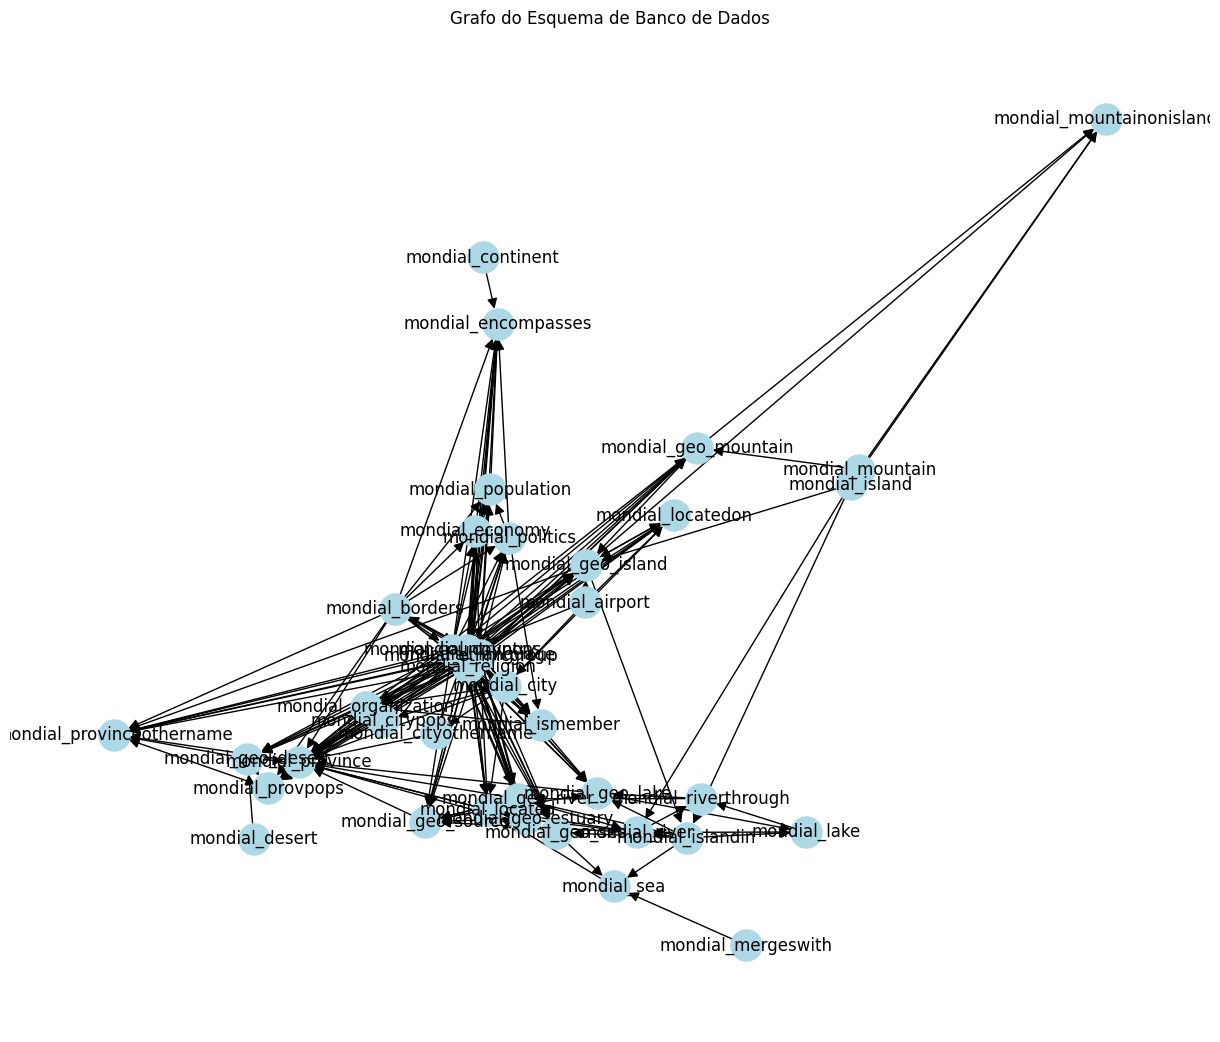

[Graph] Tabelas: 16 | Joins possíveis (edges): 31
[Coverage] Achieved 100% coverage with 4 combos.

=== Final Results ===
Total combos: 50
 Type 2: 17 combos
 Type 3: 17 combos
 Type 4: 16 combos
Coverage: 100.00%  | 16/16 tables used.

Mean frequency: 11.25
Median frequency: 11.00


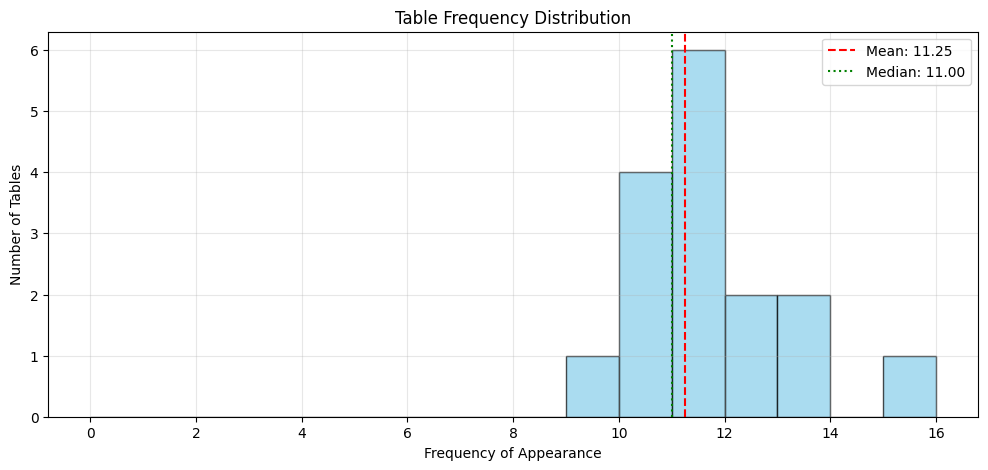

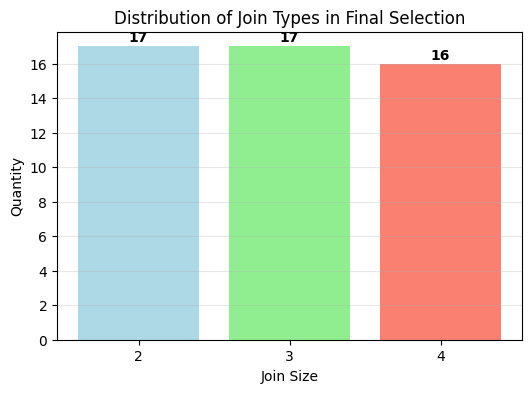

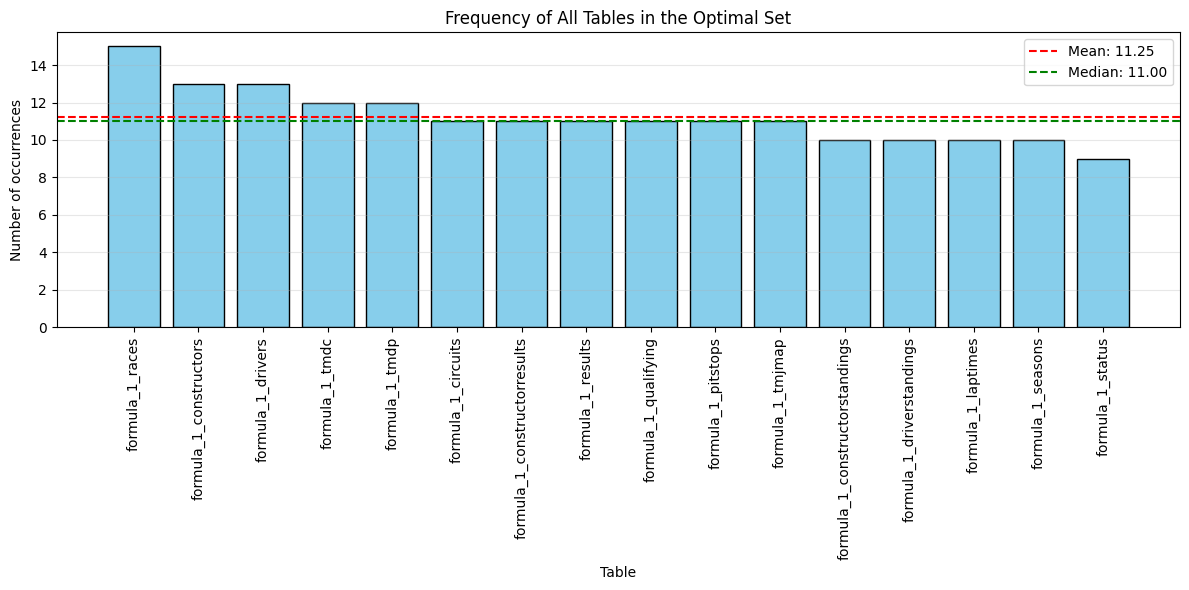

Saved optimal join combinations to joins/bird_join_combinations.csv


In [16]:
# ============================
# CÉLULA ÚNICA: FLUXO COMPLETO
# ============================

import networkx as nx
import matplotlib.pyplot as plt
import random
from collections import defaultdict
import itertools
import numpy as np
import statistics
import os
from pathlib import Path

###############################################################################
# PASSO 1: BUILD SCHEMA GRAPH
###############################################################################
def build_schema_graph(joins):
    """
    Constrói um grafo representando o esquema do banco de dados.
    Nós = tabelas
    Arestas = joins entre tabelas
    """
    G = nx.DiGraph()
    for join in joins:
        G.add_node(join.from_)
        G.add_node(join.to)
        G.add_edge(join.from_, join.to, conditions=join.on, join_obj=join)
    print(f"[Graph] Tabelas: {G.number_of_nodes()} | Joins possíveis (edges): {G.number_of_edges()}")
    return G

###############################################################################
# PASSO 2: GERA TODAS AS COMBINAÇÕES 2,3,4 QUE SEJAM CONEXAS
###############################################################################
def is_connected_subgraph(join_set):
    """
    Verifica se o conjunto de joins forma um subgrafo conexo (não-dirigido).
    """
    if not join_set:
        return False
    # Para 1 join somente, consideramos conectado
    if len(join_set) == 1:
        return True
    
    tables = set()
    for j in join_set:
        tables.add(j.from_)
        tables.add(j.to)
    
    # Montamos um grafo não-dirigido
    graph = {t: set() for t in tables}
    for j in join_set:
        graph[j.from_].add(j.to)
        graph[j.to].add(j.from_)
    
    visited = set()
    queue = [next(iter(tables))]
    visited.add(queue[0])
    
    while queue:
        node = queue.pop(0)
        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
    
    return len(visited) == len(tables)

def prepare_all_combinations(joins, max_size=4):
    """
    Gera todas as combinações possíveis de 2, 3, 4 joins que sejam conexas.
    Retorna { '2': [...], '3': [...], '4': [...] }.
    """
    combos_by_type = {"2": [], "3": [], "4": []}
    for size in [2, 3, 4]:
        if size > max_size:
            continue
        all_subsets = list(itertools.combinations(joins, size))
        valid = []
        for sset in all_subsets:
            if is_connected_subgraph(sset):
                valid.append(sset)
        combos_by_type[str(size)] = valid
    return combos_by_type

###############################################################################
# PASSO 3: SELEÇÃO DAS COMBINAÇÕES PRIORIZANDO COBERTURA=100%, BALANCE (2,3,4),
#          MÍNIMO n, E FREQUÊNCIA DE TABELAS.
###############################################################################
def get_join_type(comb):
    """
    Retorna '2','3','4' baseado no número de tabelas distintas em 'comb'.
    """
    tables = set()
    for j in comb:
        tables.add(j.from_)
        tables.add(j.to)
    tcount = len(tables)
    if tcount <= 2:
        return "2"
    elif tcount == 3:
        return "3"
    else:
        return "4"

def is_redundant(new_comb, existing_list, threshold=0.75):
    """
    Diz se new_comb é redundante frente a 'existing_list' de combos,
    se a sobreposição de tabelas >= threshold.
    """
    new_tables = set()
    for j in new_comb:
        new_tables.add(j.from_)
        new_tables.add(j.to)
    
    for comb in existing_list:
        c_tables = set()
        for jj in comb:
            c_tables.add(jj.from_)
            c_tables.add(jj.to)
        inter = len(new_tables.intersection(c_tables))
        uni = len(new_tables.union(c_tables))
        if uni == 0:
            continue
        if (inter/uni) >= threshold:
            return True
    return False

def select_balanced_combinations(
    combos_by_type, 
    all_tables, 
    min_n=30, 
    coverage_first=True
    ):
    """
    Seleciona combinações, priorizando:
    1) Cobertura 100% se coverage_first = True
    2) Equilíbrio de tipos (2,3,4)
    3) Atingir ao menos min_n combinações
    4) Frequência das tabelas (com peso menor)
    
    combos_by_type: dicionário { '2': [...], '3': [...], '4': [...] } 
    """
    selected = {"2": [], "3": [], "4": []}
    table_freq = {t: 0 for t in all_tables}
    tables_covered = set()
    
    def coverage_percent():
        return (len(tables_covered)/len(all_tables)) * 100.0
    
    def count_total():
        return sum(len(selected[t]) for t in ["2","3","4"])
    
    # Define pontuação para combo
    def combo_score(comb):
        c_tables = set()
        for j in comb:
            c_tables.add(j.from_)
            c_tables.add(j.to)
        
        # Prioriza adicionar novas tabelas se coverage < 100
        new_tables = 0
        freq_penalty = 0
        for tab in c_tables:
            if tab not in tables_covered:
                new_tables += 1
            else:
                # penaliza um pouco tabelas já muito frequentes
                if table_freq[tab] > 2:
                    freq_penalty += (table_freq[tab] - 2)**2
        
        # Score final
        return new_tables*20 - freq_penalty
    
    # Fase 1: Cobertura, se coverage_first
    coverage_done = (coverage_percent() >= 100.0)
    iters_no_progress = 0
    max_iters = 50
    
    while (coverage_first and not coverage_done) and iters_no_progress < max_iters:
        best_c = None
        best_type = None
        best_s = float('-inf')
        
        for t in ["2","3","4"]:
            for comb in combos_by_type[t]:
                if comb in selected[t]:
                    continue
                if is_redundant(comb, selected[t]):
                    continue
                sc = combo_score(comb)
                if sc > best_s:
                    best_s = sc
                    best_c = comb
                    best_type = t
        
        if best_c is None:
            iters_no_progress += 1
        else:
            selected[best_type].append(best_c)
            c_tables = set()
            for j in best_c:
                c_tables.add(j.from_)
                c_tables.add(j.to)
            for tab in c_tables:
                table_freq[tab]+=1
                tables_covered.add(tab)
            iters_no_progress = 0
        
        coverage_done = (coverage_percent() >= 100.0)
    
    if coverage_done:
        print(f"[Coverage] Achieved 100% coverage with {count_total()} combos.")
    else:
        print(f"[Coverage] Could not reach 100%. Current: {coverage_percent():.2f}%")
    
    # Fase 2: Balance de tipos e min_n
    attempts_no_improv = 0
    while count_total() < min_n and attempts_no_improv < 30:
        # Identifica o tipo sub-representado
        type_counts = {t: len(selected[t]) for t in ["2","3","4"]}
        total_c = sum(type_counts.values())
        if total_c == 0:
            # se não há nada ainda, prioriza 2
            sub_type = "2"
        else:
            sub_type = min(type_counts, key=type_counts.get)
        
        best_c = None
        best_score_ = float('-inf')
        
        for comb in combos_by_type[sub_type]:
            if comb in selected[sub_type]:
                continue
            if is_redundant(comb, selected[sub_type]):
                continue
            sc = combo_score(comb)
            if sc > best_score_:
                best_score_ = sc
                best_c = comb
        
        if best_c is None:
            # tentar outro tipo
            found_something = False
            for alt_type in ["2","3","4"]:
                if alt_type == sub_type:
                    continue
                alt_best = None
                alt_bs = float('-inf')
                for comb in combos_by_type[alt_type]:
                    if comb in selected[alt_type]:
                        continue
                    if is_redundant(comb, selected[alt_type]):
                        continue
                    sc = combo_score(comb)
                    if sc> alt_bs:
                        alt_bs= sc
                        alt_best= comb
                if alt_best:
                    selected[alt_type].append(alt_best)
                    c_tables = set()
                    for j in alt_best:
                        c_tables.add(j.from_)
                        c_tables.add(j.to)
                    for tb in c_tables:
                        table_freq[tb]+=1
                        tables_covered.add(tb)
                    found_something = True
                    break
            if not found_something:
                attempts_no_improv+=1
        else:
            selected[sub_type].append(best_c)
            c_tables = set()
            for j in best_c:
                c_tables.add(j.from_)
                c_tables.add(j.to)
            for tb in c_tables:
                table_freq[tb]+=1
                tables_covered.add(tb)
            attempts_no_improv= 0
    
    # Retorna 
    return selected, table_freq, tables_covered

###############################################################################
# PASSO 4: PLOT E SUMÁRIO
###############################################################################
def summarize_and_plot_results(selected, table_freq, all_tables):
    """
    Exibe sumário e gera gráficos:
      - Frequência de cada tabela (histograma com média e mediana)
      - Distribuição de tipos (barras)
    """
    type_counts = {t: len(selected[t]) for t in ["2","3","4"]}
    total_combos = sum(type_counts.values())
    
    print("\n=== Final Results ===")
    print(f"Total combos: {total_combos}")
    for t in ["2","3","4"]:
        print(f" Type {t}: {type_counts[t]} combos")
    
    used_tables = [t for t, f in table_freq.items() if f>0]
    coverage= len(used_tables)/len(all_tables)*100
    print(f"Coverage: {coverage:.2f}%  | {len(used_tables)}/{len(all_tables)} tables used.\n")
    
    freq_values= list(table_freq.values())
    mean_f= np.mean(freq_values) if freq_values else 0
    median_f= statistics.median(freq_values) if freq_values else 0
    
    print(f"Mean frequency: {mean_f:.2f}")
    print(f"Median frequency: {median_f:.2f}")
    
    # Grafico 1: Histograma de frequência
    plt.figure(figsize=(12,5))
    if freq_values:
        max_f= max(freq_values)
        bins= range(0, max_f+2)
        plt.hist(freq_values, bins=bins, alpha=0.7, color='skyblue', edgecolor='black')
        plt.axvline(x=mean_f, color='red', linestyle='--', label=f'Mean: {mean_f:.2f}')
        plt.axvline(x=median_f, color='green', linestyle=':', label=f'Median: {median_f:.2f}')
    plt.title("Table Frequency Distribution")
    plt.xlabel("Frequency of Appearance")
    plt.ylabel("Number of Tables")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()
    
    # Grafico 2: Distribuicao por tipo
    plt.figure(figsize=(6,4))
    sizes= ["2","3","4"]
    counts= [type_counts[s] for s in sizes]
    
    bars= plt.bar(sizes, counts, color=['lightblue','lightgreen','salmon'])
    for i, c in enumerate(counts):
        plt.text(i, c+0.1, str(c), ha='center', va='bottom', fontweight='bold')
    
    plt.title("Distribution of Join Types in Final Selection")
    plt.xlabel("Join Size")
    plt.ylabel("Quantity")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

import numpy as np
import statistics
import matplotlib.pyplot as plt

def plot_all_table_frequencies(table_freq, title="Frequency of All Tables in Combinations"):
    """
    Gera um gráfico de barras mostrando a frequência de cada tabela.
    As tabelas são ordenadas em ordem decrescente de frequência.
    Adiciona linhas horizontais indicando média e mediana.
    
    Args:
        table_freq (dict): dicionário {nome_tabela: freq_de_ocorrencia}
        title (str): título do gráfico (opcional)
    """
    
    # 1. Ordenar as tabelas por frequência (decrescente)
    sorted_items = sorted(table_freq.items(), key=lambda x: x[1], reverse=True)
    table_names = [item[0] for item in sorted_items]
    frequencies = [item[1] for item in sorted_items]
    
    # 2. Calcular média e mediana (se a lista estiver vazia, definimos 0)
    if frequencies:
        mean_freq = np.mean(frequencies)
        median_freq = statistics.median(frequencies)
    else:
        mean_freq, median_freq = 0, 0
    
    # 3. Criar figura e plotar barras
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(table_names)), frequencies, color='skyblue', edgecolor='black')
    
    # 4. Linhas horizontais: média (vermelho) e mediana (verde)
    plt.axhline(y=mean_freq, color='red', linestyle='--', label=f'Mean: {mean_freq:.2f}')
    plt.axhline(y=median_freq, color='green', linestyle='--', label=f'Median: {median_freq:.2f}')
    
    # 5. Labels e estilização
    plt.title(title)
    plt.xlabel("Table")
    plt.ylabel("Number of occurrences")
    plt.xticks(range(len(table_names)), table_names, rotation=90)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()  # Ajusta espaçamentos para não cortar legendas
    
    # Exibir ou salvar
    plt.show()

# Exemplo de uso (em outra célula ou no final do código):
# plot_all_table_frequencies(table_freq, "Frequency of All Tables in the Optimal Set")

def save_optimal_join_combinations(selected, output_path='joins/join_combination/optimal_join_combinations.csv'):
    """
    Saves the optimal join combinations to a CSV file.
    
    Args:
        selected (dict): Dictionary with keys '2', '3', '4' mapping to lists of join combinations
        output_path (str): Path where the CSV file will be saved
    """
    import pandas as pd
    
    # Create lists to store data
    types = []
    combination_ids = []
    tables_list = []
    join_conditions = []
    
    # For each type of join (2, 3, 4)
    for join_type in ["2", "3", "4"]:
        # For each combination in that type
        for i, combo in enumerate(selected[join_type], 1):
            # Get all unique tables in this combination
            tables = set()
            for join in combo:
                tables.add(join.from_)
                tables.add(join.to)
            
            # Format join conditions
            conditions = []
            for join in combo:
                if hasattr(join, 'on') and join.on:
                    conditions.append(f"{join.from_}.{join.on}")
                else:
                    conditions.append(f"{join.from_} → {join.to} (incomplete condition)")
            
            # Add to our lists
            types.append(int(join_type))
            combination_ids.append(i)
            tables_list.append(", ".join(sorted(tables)))
            join_conditions.append("; ".join(conditions))
    
    # Create DataFrame
    df = pd.DataFrame({
        'Type': types,
        'Combination': combination_ids,
        'Tables': tables_list,
        'Join Conditions': join_conditions
    })
    
    # Criar diretório se não existir
    parent = Path(output_path).parent
    if not parent.exists():
        parent.mkdir(parents=True, exist_ok=True)
    
    # Save to CSV
    df.to_csv(output_path, index=False)
    print(f"Saved optimal join combinations to {output_path}")

###############################################################################
# AGORA RODAMOS TUDO:
###############################################################################
def run_full_process(joins, min_n=50):
    # 1) build schema graph
    schema_graph = build_schema_graph(joins)
    all_tables = list(schema_graph.nodes())
    
    # 2) gerar todas as combinações possiveis
    combos_by_type= prepare_all_combinations(joins, max_size=4)
    
    # 3) selecionar combos balanceados
    selected, table_freq, covered= select_balanced_combinations(
        combos_by_type, 
        all_tables, 
        min_n=min_n,
        coverage_first=True  # prioriza 100% coverage
    )
    
    # 4) exibir e plotar
    summarize_and_plot_results(selected, table_freq, all_tables)
    plot_all_table_frequencies(table_freq, "Frequency of All Tables in the Optimal Set")
    save_optimal_join_combinations(selected, f'joins/{experiment}_join_combinations.csv')

# =======================
# EXEMPLO DE USO
# =======================
run_full_process(joins, min_n=50)

## Listas de Joins e Colunas

In [5]:
import pandas as pd

# Carregar o arquivo com as combinações ótimas de joins
join_combinations_path = f"joins/{experiment}_join_combinations.csv"
join_combinations_df = pd.read_csv(join_combinations_path)

# Criar uma lista de objetos para cada combinação de join
combination_data = []
for idx, row in join_combinations_df.iterrows():
    tipo = row['Type']
    combinacao = row['Combination']
    tabelas_str = row['Tables']
    condicoes_join = row['Join Conditions']
    
    # Extrair lista de tabelas da string
    tabelas_list = [t.strip() for t in tabelas_str.strip('"').split(',')]
    
    combination_data.append({
        "combination_id": f"{tipo}_{combinacao}",
        "tables": tabelas_list,
        "combination_str": condicoes_join
    })

print(f"Total de combinações de joins carregadas: {len(combination_data)}")
print("\nExemplo de combinação:")
print(json.dumps(combination_data[0], indent=2))

Total de combinações de joins carregadas: 50

Exemplo de combinação:
{
  "combination_id": "2_1",
  "tables": [
    "formula_1_circuits",
    "formula_1_races",
    "formula_1_tmjmap"
  ],
  "combination_str": "formula_1_circuits.['formula_1_races.circuitid=formula_1_circuits.circuitid']; formula_1_tmjmap.['formula_1_tmjmap.FROM_T=formula_1_races.YEAR']"
}


In [6]:
import json
import pandas as pd

def parse_pipe_list(s: str):
    if not isinstance(s, str) or not s.strip():
        return []
    return [x.strip() for x in s.split("|") if x.strip()]

def parse_column_ref(s: str):
    # "table.column"
    table, column = s.split(".", 1)
    return {"table": table, "column": column}

def parse_aggregation(s: str):
    # "avg(table.column)" or "count(*)"
    func, rest = s.split("(", 1)
    rest = rest.rstrip(")")
    if rest == "*":
        return {"func": func, "column": None}
    return {"func": func, "column": parse_column_ref(rest)}

def parse_filter(s: str):
    # "table.column op value"
    for op in ["<=", ">=", "!=", "=", "<", ">", "between", "in", "like"]:
        if f" {op} " in s:
            left, right = s.split(f" {op} ", 1)
            return {
                "column": parse_column_ref(left),
                "op": op,
                "value_hint": right
            }
    raise ValueError(f"Could not parse filter: {s}")


In [7]:
# Path to column combo CSV
column_combos_path = f"columns_combos/{experiment}_columns_combinations.csv"

column_combos_df = pd.read_csv(column_combos_path)

combo_data = []

for idx, row in column_combos_df.iterrows():
    db_id = row["db_id"]

    tables = row["tables"]
    select_columns = [parse_column_ref(c) for c in parse_pipe_list(row["select_columns"])]
    aggregations = [parse_aggregation(a) for a in parse_pipe_list(row["aggregations"])]
    group_by = [parse_column_ref(c) for c in parse_pipe_list(row["group_by"])]
    filters = [parse_filter(f) for f in parse_pipe_list(row["filters"])]

    order_by = (
        parse_column_ref(row["order_by"])
        if isinstance(row["order_by"], str) and row["order_by"].strip()
        else None
    )

    combo_data.append({
        "combo_id": f"{db_id}_{idx:06d}",
        "db_id": db_id,
        "tables": tables,
        "select_columns": select_columns,
        "aggregations": aggregations,
        "group_by": group_by,
        "filters": filters,
        "order_by": order_by,
        "order_dir": row["order_dir"] if isinstance(row["order_dir"], str) else None,
        # "rationale": row["rationale"]
    })

print(f"Total de column combos carregados: {len(combo_data)}")
print("\nExemplo de combo:")
print(json.dumps(combo_data[0], indent=2))


Total de column combos carregados: 65

Exemplo de combo:
{
  "combo_id": "formula_1_000000",
  "db_id": "formula_1",
  "tables": "formula_1_circuits",
  "select_columns": [
    {
      "table": "formula_1_circuits",
      "column": "country"
    },
    {
      "table": "formula_1_circuits",
      "column": "location"
    }
  ],
  "aggregations": [
    {
      "func": "count",
      "column": null
    }
  ],
  "group_by": [
    {
      "table": "formula_1_circuits",
      "column": "country"
    },
    {
      "table": "formula_1_circuits",
      "column": "location"
    }
  ],
  "filters": [],
  "order_by": null,
  "order_dir": null
}


## Geração dos Diálogos

- Aqui vamos usar os csvs de joins e de colunas para gerar os diálogos

In [8]:
from functions.llm_config import LLMConfig
from new_dialogue_generator import DialogueGenerator
from pathlib import Path

experiment = os.getenv("EXPERIMENT_NAME")
root_path = Path().absolute().parent.parent
db_connection = f"{root_path}/connections/{experiment}_db_connection.json"

dialogue_generator = DialogueGenerator(
    database_name=experiment,
    llm=LLMConfig(provider=os.getenv("LLM_PROVIDER")).get_llm(model=os.getenv("LLM_MODEL")),
    join_combination_data=combination_data,
    column_combination_data=combo_data,
    table_ddls_hashmap=table_ddls_hashmap,
    database_connection=db_connection,
    interactions=3,
    max_columns_interactions=2,
)

dialogues = dialogue_generator.create_dialogue_dataset()

print(dialogues)

 - Generating dialogue for combination 1 of 50
[Using checkpoint]Dialogue for combination 1 already exists in dialogue_dataset/bird_dialogue_dataset.json. Skipping...
 - Generating dialogue for combination 2 of 50


/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/langsmith/client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(
Failed to multipart ingest runs: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=0bff2f61-77b7-43bb-85d0-aa4d664fc232,id=0bff2f61-77b7-43bb-85d0-aa4d664fc232; trace=0bff2f61-77b7-43bb-85d0-aa4d664fc232,id=39a1077c-6159-4c6e-81cb-678f539ea0b6


[Generated dialogue] experiment_id='2' total_expected_interactions=3 interactions=[Interaction(interaction_id='1', speaker='User', utterance='What are the statuses available in the constructor results table?', intention='What are the distinct statuses in the constructor results table?', ground_truths=GroundTruth(tables_from_schema_linking=['formula_1_constructorresults'], golden_sql='SELECT DISTINCT STATUS FROM FORMULA_1_CONSTRUCTORRESULTS')), Interaction(interaction_id='2', speaker='User', utterance='How many races had each of these statuses?', intention='Count the number of races for each status in the constructor results table.', ground_truths=GroundTruth(tables_from_schema_linking=['formula_1_constructorresults'], golden_sql='SELECT STATUS, COUNT(DISTINCT RACEID) AS RACE_COUNT FROM FORMULA_1_CONSTRUCTORRESULTS GROUP BY STATUS')), Interaction(interaction_id='3', speaker='User', utterance='Show me the constructors and their nationalities for each status.', intention='Retrieve constru

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=0bff2f61-77b7-43bb-85d0-aa4d664fc232,id=39a1077c-6159-4c6e-81cb-678f539ea0b6; trace=0bff2f61-77b7-43bb-85d0-aa4d664fc232,id=6371cdd6-d2af-4b83-af99-565c915a2922; trace=0bff2f61-77b7-43bb-85d0-aa4d664fc232,id=6371cdd6-d2af-4b83-af99-565c915a2922; trace=0bff2f61-77b7-43bb-85d0-aa4d664fc232,id=0bff2f61-77b7-43bb-85d0-aa4d664fc232


[Saving dialogue] {'experiment_id': '2', 'total_expected_interactions': 3, 'interactions': [{'interaction_id': '1', 'speaker': 'User', 'utterance': 'What are the statuses available in the constructor results table?', 'intention': 'What are the distinct statuses in the constructor results table?', 'ground_truths': {'tables_from_schema_linking': ['formula_1_constructorresults'], 'golden_sql': 'SELECT DISTINCT STATUS FROM FORMULA_1_CONSTRUCTORRESULTS'}}, {'interaction_id': '2', 'speaker': 'User', 'utterance': 'How many races had each of these statuses?', 'intention': 'Count the number of races for each status in the constructor results table.', 'ground_truths': {'tables_from_schema_linking': ['formula_1_constructorresults'], 'golden_sql': 'SELECT STATUS, COUNT(DISTINCT RACEID) AS RACE_COUNT FROM FORMULA_1_CONSTRUCTORRESULTS GROUP BY STATUS'}}, {'interaction_id': '3', 'speaker': 'User', 'utterance': 'Show me the constructors and their nationalities for each status.', 'intention': 'Retrieve

...

[Saving dialogue] {'experiment_id': '16', 'total_expected_interactions': 3, 'interactions': [{'interaction_id': '1', 'speaker': 'User', 'utterance': 'Can you show me the pit stop details for each driver?', 'intention': 'Retrieve pit stop details for all drivers.', 'ground_truths': {'tables_from_schema_linking': ['formula_1_drivers', 'formula_1_pitstops'], 'golden_sql': 'SELECT D.DRIVERREF, D.FORENAME, D.SURNAME, P.STOP, P.LAP, P.TIME, P.DURATION FROM FORMULA_1_DRIVERS D JOIN FORMULA_1_PITSTOPS P ON D.DRIVERID = P.DRIVERID'}}, {'interaction_id': '2', 'speaker': 'User', 'utterance': 'How many drivers are there by nationality?', 'intention': 'Count the number of drivers grouped by nationality.', 'ground_truths': {'tables_from_schema_linking': ['formula_1_drivers'], 'golden_sql': 'SELECT NATIONALITY, COUNT(*) FROM FORMULA_1_DRIVERS GROUP BY NATIONALITY'}}, {'interaction_id': '3', 'speaker': 'User', 'utterance': 'What are the qualifying details for each driver?', 'intention': 'Retrieve qual

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=7378e197-5505-4975-b92f-0f522e1f4980,id=7378e197-5505-4975-b92f-0f522e1f4980; trace=7378e197-5505-4975-b92f-0f522e1f4980,id=4dc39c14-7c3e-484e-b898-efdf172e20fc


[Generated dialogue] experiment_id='17' total_expected_interactions=3 interactions=[Interaction(interaction_id='1', speaker='User', utterance='Which constructors have standings data with their positions in the races?', intention='Which constructors have standings data with their positions in the races?', ground_truths=GroundTruth(tables_from_schema_linking=['formula_1_constructors', 'formula_1_constructorstandings'], golden_sql='SELECT F1C.NAME, F1CS.POSITION FROM FORMULA_1_CONSTRUCTORS F1C JOIN FORMULA_1_CONSTRUCTORSTANDINGS F1CS ON F1C.CONSTRUCTORID = F1CS.CONSTRUCTORID')), Interaction(interaction_id='2', speaker='User', utterance='Can you show me the constructors along with the drivers who raced for them?', intention='Which constructors have drivers who raced for them?', ground_truths=GroundTruth(tables_from_schema_linking=['formula_1_constructors', 'formula_1_results'], golden_sql='SELECT F1C.NAME, F1R.DRIVERID FROM FORMULA_1_CONSTRUCTORS F1C JOIN FORMULA_1_RESULTS F1R ON F1C.CONST

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=7378e197-5505-4975-b92f-0f522e1f4980,id=4dc39c14-7c3e-484e-b898-efdf172e20fc; trace=7378e197-5505-4975-b92f-0f522e1f4980,id=d0dd6d98-193e-4549-85ac-e665a09fb030; trace=7378e197-5505-4975-b92f-0f522e1f4980,id=d0dd6d98-193e-4549-85ac-e665a09fb030; trace=7378e197-5505-4975-b92f-0f522e1f4980,id=7378e197-5505-4975-b92f-0f522e1f4980


KeyboardInterrupt: 